<a href="https://colab.research.google.com/github/hend-22/-IT326-Project/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/hend-22/-IT326-Project/main/Dataset/Raw_Dataset.csv"
df = pd.read_csv(url)

df.shape

(10000, 16)

#**Five-Number Summary**

####The five-number summary is used to describe the distribution of the numerical attributes using the minimum, first quartile (Q1), median, third quartile (Q3), and maximum values.

In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]


,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
min,18.0,17.5,0.0,0.5,2.0,1000.00,491.0,50.0,3.5,0.7,1.0
25%,31.0,22.3,100.0,2.0,5.3,4919.50,1354.0,61.0,6.3,1.4,3.5
50%,43.0,25.1,201.0,2.5,7.1,7396.50,1561.0,67.0,7.0,1.7,4.2
75%,56.0,27.8,303.0,3.0,8.7,10119.25,1786.0,73.0,7.6,2.1,4.8
max,69.0,38.0,730.0,5.0,14.0,23451.00,2901.0,95.0,10.9,3.4,7.5


#**Statistical Summary**

####The statistical summary provides descriptive statistics for the numerical attributes, including count, mean, standard deviation, minimum, quartiles, and maximum values.

In [ ]:
df.describe()

,Age,BMI,Caffeine_Intake_mg,Water_Intake_liters,Screen_Time_Hours,Daily_Steps,Calories_Burned,Resting_Heart_Rate,Daily_Sleep_Hours,Deep_Sleep_Hours,Sleep_Quality_Score
count,10000.000000,9790.000000,9794.000000,10000.000000,10000.000000,10000.000000,10000.000000,9781.000000,9810.000000,10000.000000,10000.000000
mean,43.539400,25.087406,207.365224,2.502550,7.060990,7963.857000,1573.986300,66.944177,6.957951,1.750610,4.170080
std,14.911636,3.905276,137.681368,0.802058,2.443689,4021.490815,320.153851,8.450527,0.907726,0.467773,0.914011
min,18.000000,17.500000,0.000000,0.500000,2.000000,1000.000000,491.000000,50.000000,3.500000,0.700000,1.000000
25%,31.000000,22.300000,100.000000,2.000000,5.300000,4919.500000,1354.000000,61.000000,6.300000,1.400000,3.500000
50%,43.000000,25.100000,201.000000,2.500000,7.100000,7396.500000,1561.000000,67.000000,7.000000,1.700000,4.200000
75%,56.000000,27.800000,303.000000,3.000000,8.700000,10119.250000,1786.000000,73.000000,7.600000,2.100000,4.800000
max,69.000000,38.000000,730.000000,5.000000,14.000000,23451.000000,2901.000000,95.000000,10.900000,3.400000,7.500000


#**Outliers Detection**

####Outliers are detected using the Interquartile Range (IQR) method. Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered outliers.

In [ ]:
# Select numerical attributes
numeric_columns = df.select_dtypes(include='number').columns

# Detect outliers using the IQR method
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(column, ":", len(outliers), "outliers")

Age : 0 outliers
BMI : 25 outliers
Caffeine_Intake_mg : 25 outliers
Water_Intake_liters : 47 outliers
Screen_Time_Hours : 38 outliers
Daily_Steps : 182 outliers
Calories_Burned : 59 outliers
Resting_Heart_Rate : 7 outliers
Daily_Sleep_Hours : 43 outliers
Deep_Sleep_Hours : 9 outliers
Sleep_Quality_Score : 43 outliers


#**Boxplots**

####Boxplots are used to visualize the distribution of the numerical attributes and identify potential outliers.

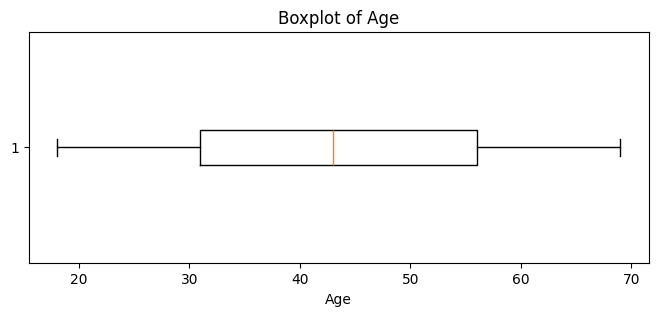

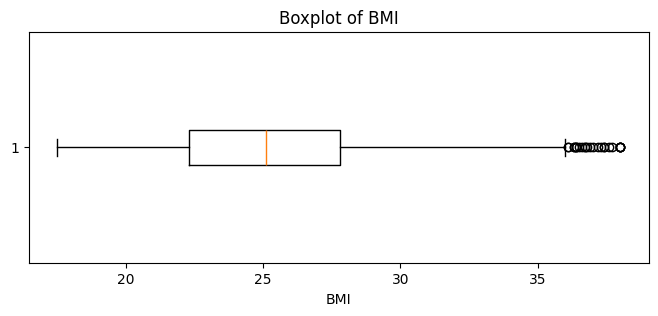

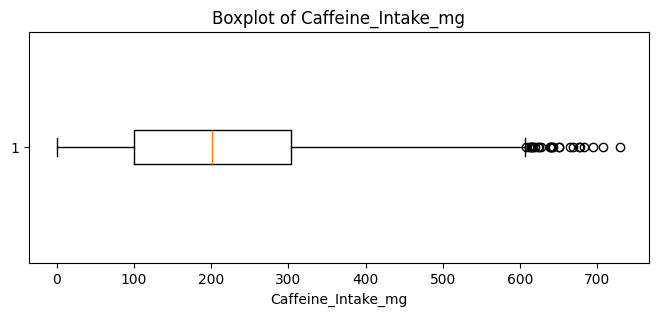

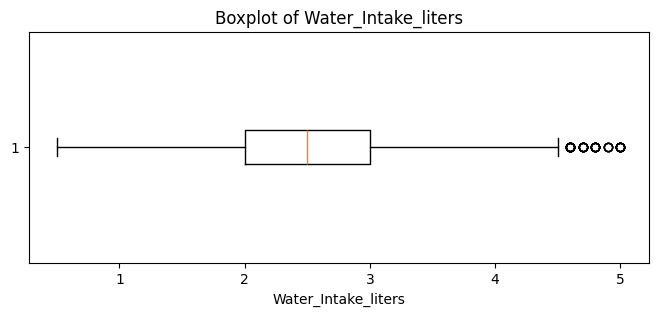

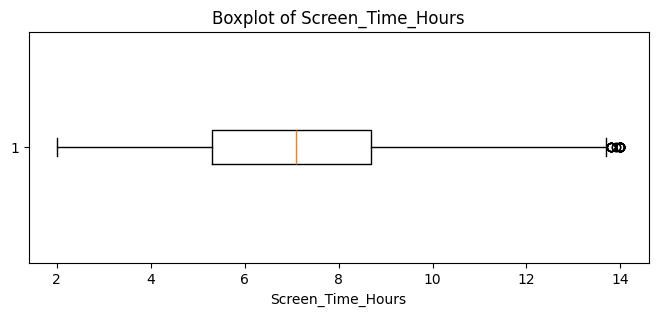

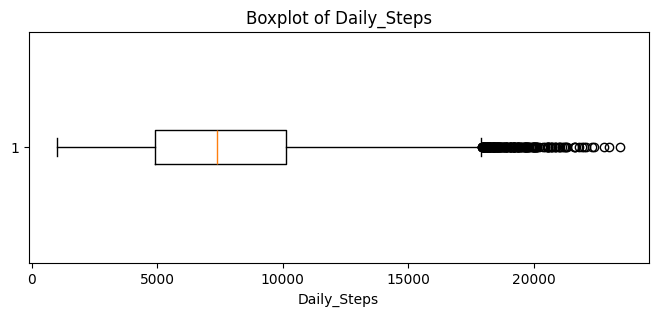

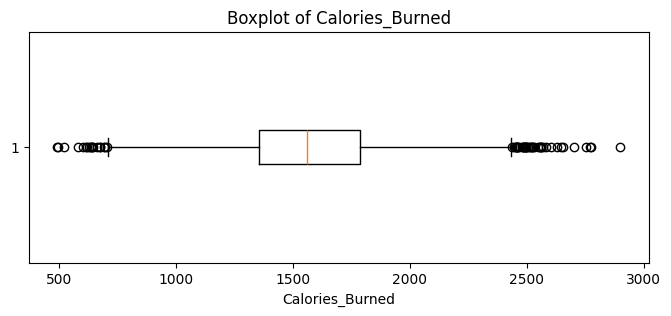

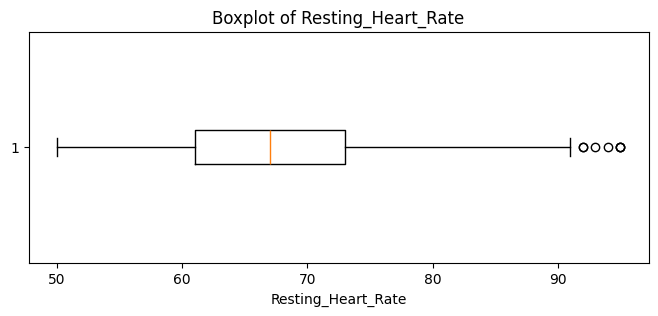

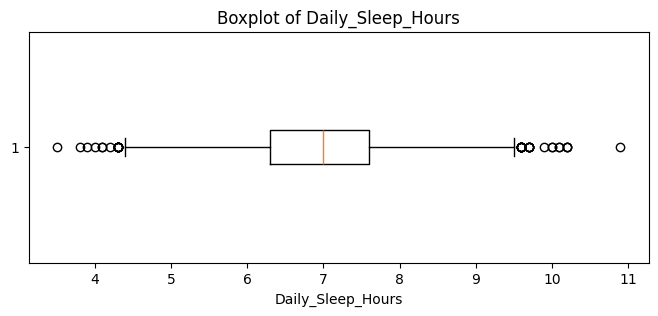

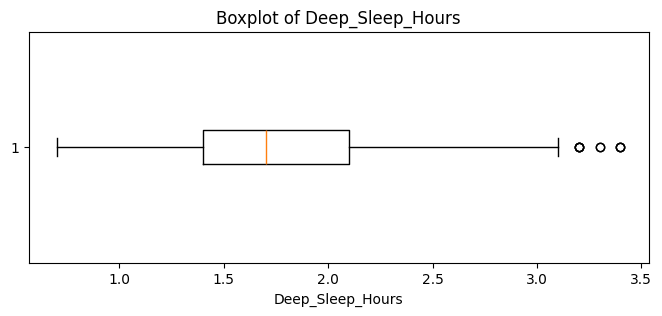

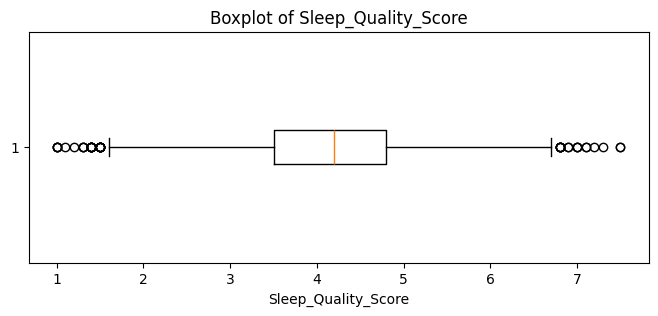

In [ ]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[column].dropna(), vert=False)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

#**Boxplot Analysis**

####The boxplots show that most numerical attributes contain outliers, while Age has no detected outliers. Daily_Steps has the highest number of outliers, with 182 values identified using the IQR method. Other attributes, such as BMI, Caffeine_Intake_mg, Water_Intake_liters, Screen_Time_Hours, Calories_Burned, Resting_Heart_Rate, Daily_Sleep_Hours, Deep_Sleep_Hours, and Sleep_Quality_Score also contain outliers. These results indicate that the outliers should be considered during the preprocessing stage before applying the data mining techniques.

##Histograms and Variable Distributions


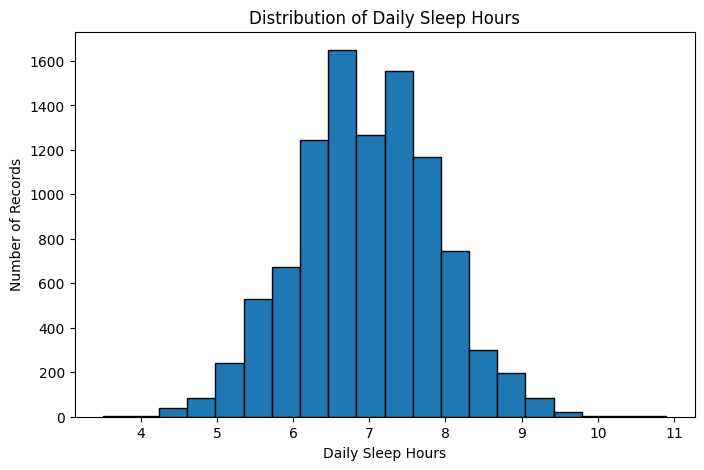

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Daily_Sleep_Hours'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Daily Sleep Hours')
plt.xlabel('Daily Sleep Hours')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:**  Most daily sleep-hour values are concentrated between approximately 6 and 8 hours. Fewer records appear at very low or high sleep durations. The distribution should be considered when checking unusual values during preprocessing.

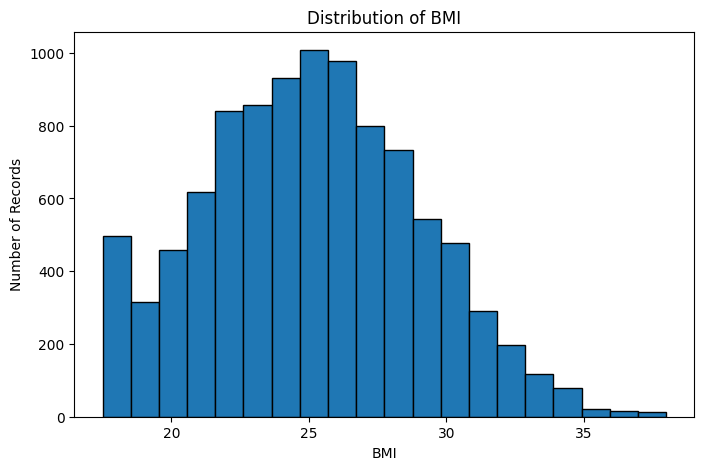

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df['BMI'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most BMI values are concentrated between approximately 22 and 28, with a peak near 25. Higher BMI values are less frequent and form a tail on the right. These values should be checked during preprocessing before deciding whether they need any treatment.


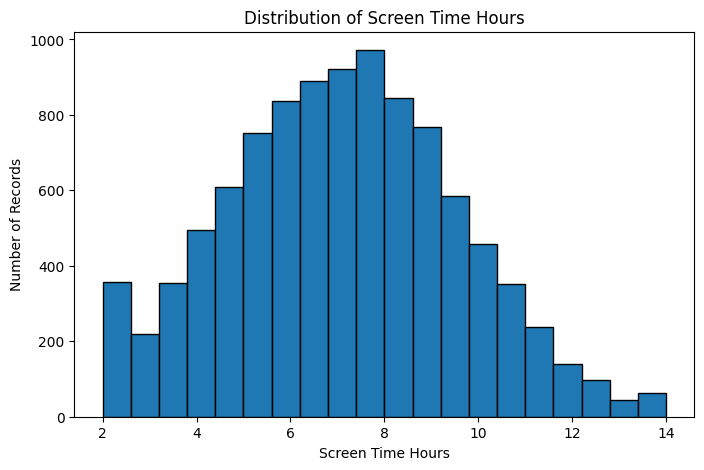

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df['Screen_Time_Hours'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Screen Time Hours')
plt.xlabel('Screen Time Hours')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most screen-time values are concentrated between approximately 5 and 10 hours, with the highest frequency around 7–8 hours. Very low and very high screen-time values are less common. Values at the ends of the distribution should be reviewed during preprocessing before deciding whether any treatment is needed.

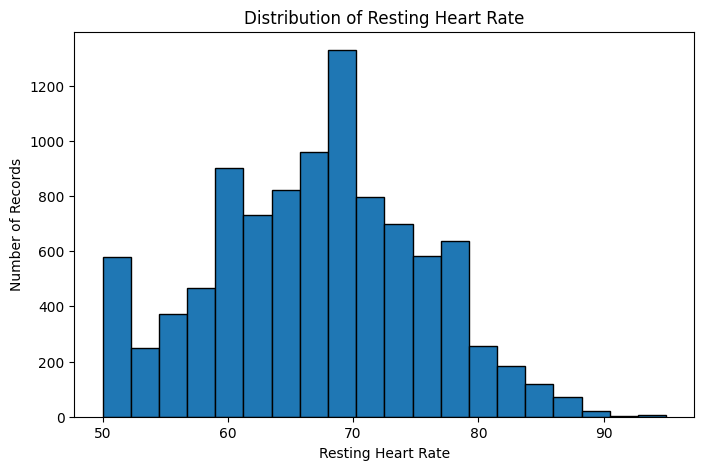

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df['Resting_Heart_Rate'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Resting Heart Rate')
plt.xlabel('Resting Heart Rate')
plt.ylabel('Number of Records')
plt.show()

**Interpretation:** Most resting heart rate values are concentrated between approximately 58 and 78, with the highest frequency around 68–70. Values above 85 are less common. These high values should be reviewed during preprocessing before deciding whether they require treatment.